### Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_curve, roc_auc_score, mean_absolute_error

import sys
sys.path.append('..')

from src.utils.dataloading import FeaturesDataset
from src.utils.model import AgeNet
from src.utils.utils import evaluate

# Evaluating the model

## Setup

In [2]:
# device setup
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cuda.


### loading

In [3]:
# loading the model
model_path = "../data/model/AgeNet.pt"

model = AgeNet(seq_len=4, d_model=1280, nhead=8)
model.load_state_dict(torch.load(model_path, weights_only=True, map_location=device))
model.backbone.freeze()
model.use_precompute()

C:\Users\mohal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [4]:
# loading the data
data_path = "../data/features"

val_features  = FeaturesDataset(data_path, "val")
test_features = FeaturesDataset(data_path, "test")

val_loader  = DataLoader(val_features, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_features, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

## Performance measure

### inference

We will mainly use the test set to evaluate the model

In [5]:
val_preds, val_labels  = evaluate(model=model, loader=val_loader, device=device)
test_preds, test_labels = evaluate(model=model, loader=test_loader, device=device)

### classification performance

Let's start by evaluating the performance of the classification head. We first examine its classification accuracy

In [6]:
# accuracy at a threshold of 0.5
accuracy = accuracy_score(test_labels["person"], test_preds["person"] > 0.5)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9984


Since there is a class imbalance between positive examples (persons) and negative examples (background), a model that predicts every sample as a person could still achieve a high accuracy. Therefore, accuracy alone is not a reliable performance metric. Instead, we use the ROC-AUC score or F1 score to better evaluate the model's ability to distinguish between the two classes.

A practical approach is to first select an optimal classification threshold using the validation set, and then apply this threshold when computing the F1 score on the test set.

Lets now start by looking at the ROC curve

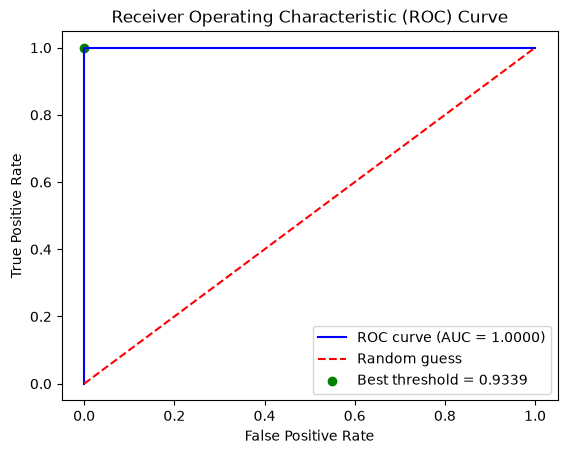

In [7]:

fpr, tpr, thresholds = roc_curve(val_labels["person"], val_preds["person"])
val_auc = roc_auc_score(val_labels["person"], val_preds["person"])
# selecting the threshold with the best trade-off between TPR and FPR
threshold_idx = np.argmax(tpr - fpr)
threshold = thresholds[threshold_idx]

# plotting the ROC curve
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {val_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.scatter(fpr[threshold_idx], tpr[threshold_idx], color='green', label=f'Best threshold = {threshold:.4f}')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Next, we report the AUC and F1 score on the test set.

In [8]:
test_auc = roc_auc_score(test_labels["person"], test_preds["person"])
test_f1  = f1_score(test_labels["person"], test_preds["person"] > threshold)

print(f"Test AUC score: {test_auc:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Test AUC score: 0.9999
Test F1 score: 0.9981


We observe that the classification performance is very strong, with both a high ROC-AUC score and a high F1 score. This is not the result of data leakage; rather, it reflects the simplicity of the classification task, which is to distinguish images containing a person from background scenery.

To make the classification task more challenging, the dataset could be extended with spoofing or fraud examples. For instance, images of someone holding a photograph of another person, wearing a realistic mask, or using disguises such as a fake mustache could be labeled as negative examples. This would require the model to distinguish genuine persons from fraudulent or spoofed representations rather than simply detecting the presence of a face. However exploring such scenarios is beyond the scope of this project but  is a good idea for future work.

### regression performance

For the regression head, the evaluation is more straightforward, as we can report either the mean squared error (MSE), the mean absolute error (MAE), or both. Since MAE is more robust to outliers, and there is no strong need to emphasize larger errors in this context, we choose to report only the MAE.

In [9]:
isPerson = test_labels["person"] == 1
test_mae = mean_absolute_error(test_labels["age"][isPerson], test_preds["age"][isPerson])
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 8.1096
